# Bellabeat Wellness Technology Case Study Project

## Project Overview

## Ask

## Prepare

## Process

## Analyze

## Share

## Act

## Conclusion

**Business Objective**: 

Bellabeat is a successful small company with the potential to becoming a larger player in the global smart device market. Analyzing non-bellabeat smart device fitbit data could lead to new growth opportunities, and to discover actionable insights into how comsumers are using their smart devices, then apllying those insights to one specific bellabeat product, and use them to guide Bellabeat marketing strategy.

*Stakeholders*:

* **Urška Sršen**: Bellabeat co-founder and chief creative officer. She has an artistic background and values beautifully designed technology that empowers women.
  
* **Sando Mur**:Bellabeat co-founder and mathematician,key member of the executive team.

* **Bellabeat’s marketing analytics team**: My peers who will help implement the strategy.

# 01. Ask

**Business Task**

Analyze non-Bellabeat wearable (Fitbit) usage data to uncover consumer trends and guide Bellabeat’s product and marketing strategy.

**Key Question**
* What are the trends in smart device usage? 
* How do these trends apply to Bellabeat’s customers? 
* How can these trends shape Bellabeat’s marketing strategy?

# 02. Prepare

*Data Sources & Credibility*:

* For this analysis, I utilized the FitBit Fitness Tracker Data (public domain, made available by Mobius on Kaggle). This dataset contains personal fitness tracking data from 33 users who consented to share minute-level output for physical activity, heart rate, and sleep monitoring over a 31-day period in 2016.
  
* Data Limitations (ROCCC Analysis): While the data provides excellent minute-level and daily behavioral metrics, it has notable limitations regarding Reliability and Comprehensiveness. The sample size is extremely small (33 users), and it lacks demographic context such as gender, age, or location. Because Bellabeat specifically targets women, the absence of gender identifiers means this data must be treated as a proxy for general smart device usage rather than a perfectly representative sample of Bellabeat's exact target audience. Additionally, the data is from 2016, meaning broad trends are still applicable, but micro-behaviors may have shifted.

# 03. Process

*Data Cleaning & Processing*:

I utilized Python (Pandas) to process, clean, and merge the datasets. I focused primarily on the dailyActivity_merged and, as these metrics closely align with the tracking capabilities of the Bellabeat "Time" wellness watch.

Data Cleaning: I identified 33 unique users in the activity data, but only 24 unique users in the sleeping data, indicating that not all users wore their trackers to bed. I reformatted the date strings into standard datetime objects and renamed the date columns to ensure uniformity. I also removed all duplicate rows from the dataset.

_Data Transformation: I performed a LEFT JOIN on the Id and Date columns. This preserved all daily activity records while appending sleep data where available. Finally, I extracted the Day_ofWeek from the date column to allow for behavioral trend analysis by day.

**Import Some Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import datetime as dt
#pd.set_option('max_column')

In [2]:
# prepare the Dataset
df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv') 

In [3]:
df.shape

(940, 15)

In [4]:
# names of the columns
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

preview of the Data

In [5]:
df. head(13)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863
5,1503960366,4/17/2016,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728
6,1503960366,4/18/2016,13019,8.59,8.59,0.0,3.25,0.64,4.71,0.0,42,16,233,1149,1921
7,1503960366,4/19/2016,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035
8,1503960366,4/20/2016,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786
9,1503960366,4/21/2016,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775


the Data types

In [6]:
df.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

In [7]:
#  convert Id to text/string and ActivityDate to datetime format

df['Id'] = df['Id']. astype(str)
df['ActivityDate'] = pd. to_datetime(df['ActivityDate'], format='%m/%d/%Y')
df.dtypes

Id                                  object
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

In [8]:
# how to find out if two columns share thesame values
df['distance_diff'] = df['TotalDistance'] - df['TrackerDistance']

In [9]:
df['distance_diff'].value_counts()

distance_diff
0.000000    925
1.830000      1
0.190001      1
0.040000      1
0.810000      1
1.049999      1
0.760000      1
1.070000      1
0.980000      1
0.900001      1
1.140000      1
1.160000      1
0.880000      1
0.460000      1
1.160000      1
1.060000      1
Name: count, dtype: int64

In [10]:
df.query('distance_diff>0.0')

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,distance_diff
689,6962181067,2016-04-21,11835,9.71,7.88,4.081692,3.99,2.10,3.51,0.11,53,27,214,708,2179,1.830000
693,6962181067,2016-04-25,13239,9.27,9.08,2.785175,3.02,1.68,4.46,0.10,35,31,282,637,2194,0.190001
707,6962181067,2016-05-09,12342,8.72,8.68,3.167822,3.90,1.18,3.65,0.00,43,21,231,607,2105,0.040000
711,7007744171,2016-04-12,14172,10.29,9.48,4.869783,4.50,0.38,5.41,0.00,53,8,355,1024,2937,0.810000
712,7007744171,2016-04-13,12862,9.65,8.60,4.851307,4.61,0.56,4.48,0.00,56,22,261,1101,2742,1.049999
713,7007744171,2016-04-14,11179,8.24,7.48,3.285415,2.95,0.34,4.96,0.00,34,6,304,1096,2668,0.760000
717,7007744171,2016-04-18,14816,10.98,9.91,4.930550,3.79,2.12,5.05,0.02,48,31,284,1077,2832,1.070000
718,7007744171,2016-04-19,14194,10.48,9.50,4.942142,4.41,0.76,5.31,0.00,53,17,304,1066,2812,0.980000
719,7007744171,2016-04-20,15566,11.31,10.41,4.924841,4.79,0.67,5.86,0.00,60,33,347,1000,3096,0.900001
724,7007744171,2016-04-25,18229,13.34,12.20,4.861792,4.31,1.37,7.67,0.00,51,24,379,986,3055,1.140000


In [11]:
# rename the columns
df.columns = df.columns.str.lower()
df.columns

Index(['id', 'activitydate', 'totalsteps', 'totaldistance', 'trackerdistance',
       'loggedactivitiesdistance', 'veryactivedistance',
       'moderatelyactivedistance', 'lightactivedistance',
       'sedentaryactivedistance', 'veryactiveminutes', 'fairlyactiveminutes',
       'lightlyactiveminutes', 'sedentaryminutes', 'calories',
       'distance_diff'],
      dtype='object')

In [12]:
df.rename(columns={
'activitydate':'activity_date', 
   'totalsteps':'total_steps', 
   'totaldistance':'total_distance', 
   'trackerdistance':'tracker_distance',
   'loggedactivitiesdistance':'logged_activities_distance', 
   'veryactivedistance':'very_active_distance',
   'moderatelyactivedistance':'moderately_active_distance', 
   'lightactivedistance':'light_active_distance',
   'sedentaryactivedistance':'sedentary_active_distance', 
   'veryactiveminutes':'very_active_minutes', 
   'fairlyactiveminutes':'fairly_active_minutes',
   'lightlyactiveminutes':'lightly_active_minutes', 
   'sedentaryminutes':'sedentary_minutes'
}, inplace=True)

df.columns


Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff'],
      dtype='object')

In [13]:
# create columns

day_of_week = df['activity_date'].dt.day_name()
df['day_of_week'] = day_of_week

df['n_day_of_week'] = df['activity_date'].dt.weekday #0 monday 6 sunday

In [14]:
df.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff', 'day_of_week', 'n_day_of_week'],
      dtype='object')

In [15]:
# chhecking for duplicate
df.duplicated().sum()

np.int64(0)

In [16]:
# checking null values
df.isna().sum()

id                            0
activity_date                 0
total_steps                   0
total_distance                0
tracker_distance              0
logged_activities_distance    0
very_active_distance          0
moderately_active_distance    0
light_active_distance         0
sedentary_active_distance     0
very_active_minutes           0
fairly_active_minutes         0
lightly_active_minutes        0
sedentary_minutes             0
calories                      0
distance_diff                 0
day_of_week                   0
n_day_of_week                 0
dtype: int64

In [17]:
# subset the data
df = df[['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff', 'day_of_week', 'n_day_of_week']].copy()

In [18]:
df.head(4)

,id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,distance_diff,day_of_week,n_day_of_week
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,0.0,Tuesday,1
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,0.0,Wednesday,2
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,0.0,Thursday,3
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,0.0,Friday,4


In [19]:
df['id'].value_counts()

id
1503960366    31
1624580081    31
1844505072    31
1927972279    31
2022484408    31
2320127002    31
2026352035    31
4020332650    31
2873212765    31
4445114986    31
4319703577    31
4388161847    31
8378563200    31
6962181067    31
5553957443    31
4702921684    31
4558609924    31
8877689391    31
8583815059    31
8053475328    31
7086361926    31
1644430081    30
5577150313    30
3977333714    30
6290855005    29
8792009665    29
6117666160    28
7007744171    26
6775888955    26
3372868164    20
8253242879    19
2347167796    18
4057192912     4
Name: count, dtype: int64

# 04. Analyze

**summary of analysis ( key findings)**:

* **Finding 1**: Users spend approximately 81% of their monitored time sedentary. The chart shows that the majority of monitored time is spent being sedentary, while only a small proportion is dedicated to moderate and vigorous activities.
  
* **Finding 2**: Average daily steps are approximately 7,800, below the recommended 10,000 steps. The bar chart shows clear differences in physical activity throughout the week. Users recorded the highest average daily steps on Saturday (approximately 8,400 steps), followed closely by Wednesday. Thursday recorded the lowest average step count (approximately 7,100 steps). The horizontal average line indicates users average about 7,800 steps per day, which is below the recommended 10,000 daily steps.

* **Finding 3**: There is a strong positive relationship between daily steps and calories burned. The scatter plot demonstrates a strong positive correlation between total steps and calories burned. As daily step counts increase, calorie expenditure also increases consistently. Highly active users (red points) are concentrated in the upper-right portion of the chart, indicating both high step counts and high calorie burn, while sedentary users are clustered at lower step counts and lower calorie expenditure. Although a few outliers exist, the overall trend confirms that walking is a major contributor to daily energy expenditure.


In [20]:
# analysis
# categories
# sedentary: less than 6200 on average
# active: between 6200 and 12000 on average
# very active: more than 12000

id_grp = df.groupby(['id'])
id_avg_step = id_grp['total_steps'].mean().sort_values(ascending=False)
id_avg_step = id_avg_step.to_frame()

conditions = [
    (id_avg_step['total_steps'] <= 6200),
    (id_avg_step['total_steps'] > 6200) & (id_avg_step['total_steps'] < 12000),
    (id_avg_step['total_steps'] >= 12000)
]
values = ['sedentary','active','very_active']
id_avg_step['activity_level'] = np.select(
    conditions,
    values,
    default='unknown'
)

id_activity_level = id_avg_step['activity_level']

df['activity_level'] = [id_activity_level[c] for c in df['id']] 

In [21]:
df.describe()

,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,distance_diff,n_day_of_week
count,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574,0.014351,2.918085
min,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000,0.000000,1.000000
50%,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000,0.000000,3.000000
75%,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,0.000000,5.000000
max,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000,1.830000,6.000000
std,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862,0.124458,1.942379


# 05. Share

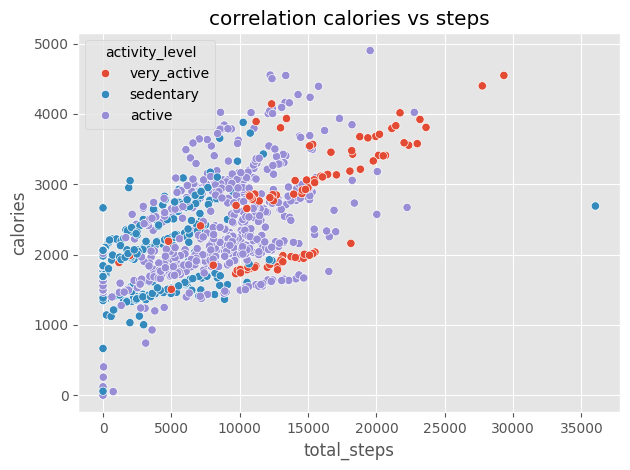

In [22]:
# share phase
# correlation between stepsand calories burned

ax = sns.scatterplot(x='total_steps', y='calories',data=df, hue=df['activity_level'])

plt.title('correlation calories vs steps')

plt.tight_layout()
plt.show()

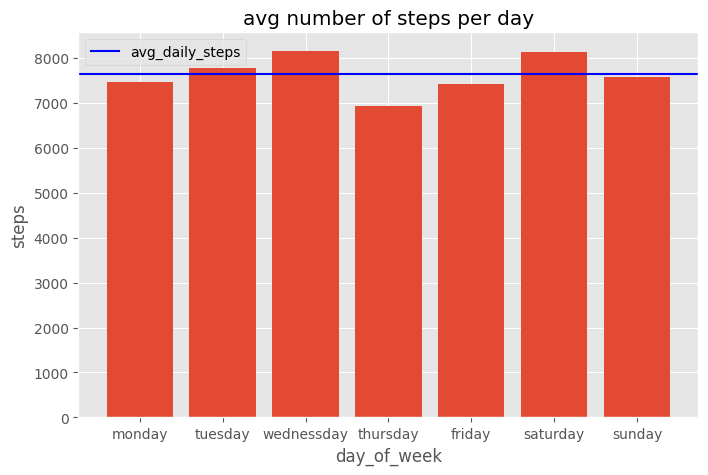

In [23]:
# average steps per day
day_of_week = ['monday', 'tuesday', 'wednessday', 'thursday', 'friday', 'saturday', 'sunday']
fig, ax =plt.subplots(1, 1, figsize=(8, 5))

day_grp =df.groupby(['day_of_week'])
avg_daily_steps = day_grp['total_steps'].mean()
avg_steps = df['total_steps'].mean()

plt.bar(avg_daily_steps.index, avg_daily_steps)

ax.set_xticks(range(len(day_of_week)))
ax.set_xticklabels(day_of_week)

ax.axhline(y=avg_daily_steps.mean() ,color='blue',label='avg_daily_steps')

ax.set_ylabel('steps')
ax.set_xlabel('day_of_week')
ax.set_title('avg number of steps per day')
plt.legend()
plt.show()

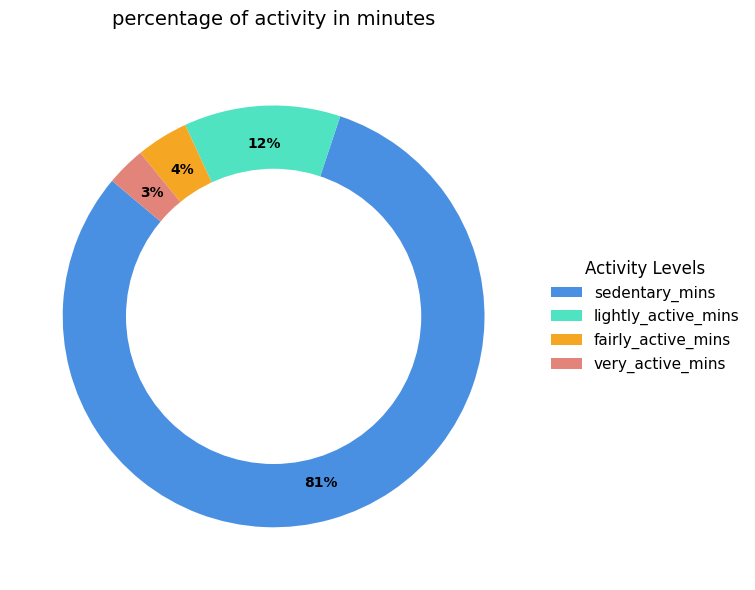

In [24]:
# percentage of activity in minutes

very_active_mins = df['very_active_minutes'].sum()
fairly_active_mins = df['fairly_active_minutes'].sum()
lightly_active_mins = df['lightly_active_minutes'].sum()
sedentary_mins = df['sedentary_minutes'].sum

# Data updated with minute-specific snake_case labels
categories = ['sedentary_mins', 'lightly_active_mins', 'fairly_active_mins', 'very_active_mins']
percentages = [81, 12, 4, 3] 
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#E2847A']

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the pie chart slices
wedges, texts, autotexts = ax.pie(
    percentages, 
    autopct='%1.0f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.82,
    textprops=dict(color="black")
)

# Style the percentage text inside the slices
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Draw a blank circle at the center to create the donut look (keeping the center empty)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Position the category labels and color blocks strictly on the right side
ax.legend(
    wedges, 
    categories,
    title="Activity Levels",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# Set the updated title as requested
plt.title('percentage of activity in minutes', fontsize=14, pad=20)
plt.tight_layout()

# Display the chart
plt.show()

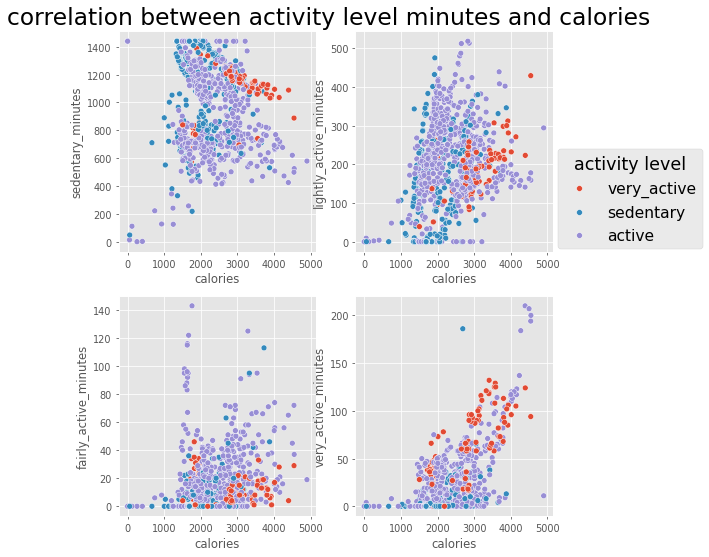

In [25]:
# correlation between activity level in minutes

n_days_of_week = [0,1,2,3,4,5,6]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,9),dpi=70)

sns.scatterplot(data=df, x='calories', y='sedentary_minutes', hue='activity_level', ax=axes[0,0],legend=False)
sns.scatterplot(data=df, x='calories', y='lightly_active_minutes', hue='activity_level', ax=axes[0,1],legend=False)
sns.scatterplot(data=df, x='calories', y='fairly_active_minutes', hue='activity_level', ax=axes[1,0],legend=False)
sns.scatterplot(data=df, x='calories', y='very_active_minutes', hue='activity_level', ax=axes[1,1],legend=True)

plt.legend(title = 'activity level', fontsize=16, title_fontsize=18, bbox_to_anchor = (1.8, 1.7))

fig.suptitle('correlation between activity level minutes and calories',x=0.5,y=0.92,fontsize=24)

plt.show()

# 06. Act

**Top 3 Strategic Recommendations for Bellabeat** 

*1. Reduce Sedentary Time*

Introduce personalized inactivity reminders and hourly movement alerts to encourage users to take short walks or stretch after prolonged sitting. Since sedentary time accounts for 81% of monitored activity, reducing inactivity offers the greatest opportunity to improve health outcomes.

*2. Encourage Daily Step Goals*

Implement personalized daily step targets, achievement badges, and weekly walking challenges. Increasing daily steps will help users burn more calories and maintain a more active lifestyle.

*3. Personalize Health Coaching*

Use Bellabeat's smart device data to provide tailored recommendations based on each user's activity level. Examples include suggesting moderate exercise for inactive users, recommending recovery after intense activity, and sending motivational messages during weekdays when activity tends to decline.

**Conclusion**

The analysis indicates that Bellabeat users have high sedentary behavior, moderate daily step counts, and a strong connection between walking and calorie expenditure. These insights provide a clear opportunity for Bellabeat to enhance user engagement through personalized coaching, movement reminders, and activity-based challenges that encourage healthier daily habits.

**Sources**: Fitbit usage data; industry reports on wearables; Pew survey on tracker usage; Bellabeat product info. Each cited source supports the findings and recommendations above.